# Simulation-derived 5G/UAS cyber-incident telemetry

The experiment run matrix. Every run is one manifest: a PX4 drone flies the
mission in Gazebo, the recorded pose drives a Simu5G network under the
manifest's network settings, and the bridge joins the two into the 44 column
dataset. One parameter group changes per run, and the baseline runs first.

Sections 1 to 3 run the matrix. Section 4 builds the final dataset and its
reports. Section 5 looks at the results.

## 1. Setup

In [1]:
import subprocess
import sys
import time
from pathlib import Path

import pandas as pd
import yaml

HERE = Path.cwd()
FINAL = HERE / "data/drone_network_telemetry_cosim.csv"
HEADLESS = False   # True: no Gazebo window and no play click, physics starts at once

manifests = {p.stem: yaml.safe_load(p.read_text()) for p in sorted((HERE / "manifests").glob("*.yaml"))}
# Baseline first, then the benign variations, then suspicious, then malicious.
RUNS = sorted(manifests, key=lambda r: (not r.startswith("B_BASE"), r[0] != "B", r[0] != "S", r))


# Run one step. The output is shown here and, if a log is given, saved there too.
def step(title, command, log=None):
    print(f"\n {title} ", flush=True)
    result = subprocess.run([sys.executable] + command, cwd=HERE, capture_output=True, text=True)
    print(result.stdout, end="")
    if log:
        Path(log).write_text(result.stdout)
    if result.returncode:
        print(result.stderr)
        raise SystemExit(f"[FAILED] {title.strip()}")


# The last pose trace is written only when the whole recording succeeded.
def recorded(run):
    drones = manifests[run]["simulation"]["drone_count"]
    last = f"{run}_pose{f'_d{drones - 1}' if drones > 1 else ''}.txt"
    return (HERE / "trace" / last).is_file()

## 2. The run matrix

In [2]:
rows = []
for run in RUNS:
    m = manifests[run]
    s, a = m["simulation"], m["attack"]
    rows.append({"run": run, "family": m["scenario_family"], "drones": s["drone_count"],
                 "speed": s["mission_speed_mps"], "duration": s["duration_sec"],
                 "window": s["aggregation_window_sec"], "cells": s["cells"],
                 "load": s["background_traffic"], "slices": s["network_slice_profile"],
                 "radio": s["wireless_condition"], "profile": s["mission_profile"],
                 "attack": a["attack_type"], "intensity": a["intensity"],
                 "recorded": recorded(run)})
matrix = pd.DataFrame(rows).set_index("run")
print(f"{len(matrix)} runs: " + ", ".join(f"{n} {f}" for f, n in matrix.family.value_counts().items()))
matrix

43 runs: 21 benign, 14 malicious, 8 suspicious


,family,drones,speed,duration,window,cells,load,slices,radio,profile,attack,intensity,recorded
run,,,,,,,,,,,,,
B_BASE_001,benign,1,3.0,135,1.0,1,low,single_mission_slice,good,route,none,off,True
B_BASE_002,benign,1,3.0,135,1.0,1,low,single_mission_slice,good,route,none,off,True
B_BASE_003,benign,1,3.0,135,1.0,1,low,single_mission_slice,good,route,none,off,True
B_CELLS_2_001,benign,1,3.0,135,1.0,2,low,single_mission_slice,good,route,none,off,True
B_CELLS_3_001,benign,1,3.0,135,1.0,3,low,single_mission_slice,good,route,none,off,True
B_DRONES_3_001,benign,3,3.0,135,1.0,1,low,single_mission_slice,good,route,none,off,True
B_DRONES_5_001,benign,5,3.0,135,1.0,1,low,single_mission_slice,good,route,none,off,True
B_DURATION_10_001,benign,1,3.0,600,1.0,1,low,single_mission_slice,good,patrol,none,off,True
B_DURATION_20_001,benign,1,3.0,1200,1.0,1,low,single_mission_slice,good,patrol,none,off,True


## 3. Fly and record one mission per run

Gazebo opens paused for each run. Press play in the window and the mission
starts; with `HEADLESS = True` there is nothing to click. The bag begins
recording once physics is running and the topic rates have been measured.
Speed, duration, drone count and mission profile come from the manifest. A
run with several drones records one real flight per drone, one after the
other, and Simu5G later flies them together.

Any run that is already recorded is skipped, so this cell can be re-run after
an interruption.

In [3]:
for run in RUNS:
    if recorded(run):
        print(f"\n***** {run} already recorded *****")
        continue
    print(f"\n***** {run} *****")
    step(f"Record {run}", ["record_mission.py", "--run-id", run] + (["--headless"] if HEADLESS else []))
    time.sleep(5)


***** B_BASE_001 already recorded *****

***** B_BASE_002 already recorded *****

***** B_BASE_003 already recorded *****

***** B_CELLS_2_001 already recorded *****

***** B_CELLS_3_001 already recorded *****

***** B_DRONES_3_001 already recorded *****

***** B_DRONES_5_001 already recorded *****

***** B_DURATION_10_001 already recorded *****

***** B_DURATION_20_001 already recorded *****

***** B_DURATION_5_001 already recorded *****

***** B_HOVER_001 already recorded *****

***** B_LOAD_HIGH_001 already recorded *****

***** B_LOAD_MEDIUM_001 already recorded *****

***** B_SLICE_DUAL_001 already recorded *****

***** B_SLICE_TRIPLE_001 already recorded *****

***** B_SPEED_FAST_001 already recorded *****

***** B_SPEED_SLOW_001 already recorded *****

***** B_WINDOW_0P5_001 already recorded *****

***** B_WINDOW_5_001 already recorded *****

***** B_WIRELESS_EDGE_001 already recorded *****

***** B_WIRELESS_MODERATE_001 already recorded *****

***** S1_HANDOVER_001 already rec

## 4. Network scenario, bridge and validation, one run at a time

Simu5G builds each network from the run's pose trace and measured topic rates.
The bridge joins them with the manifest at the manifest's aggregation window,
and every per-run dataset is validated before anything is concatenated. The
validator output is kept in reports/.

A run whose validation file already exists is skipped, so this cell can be
re-run after an interruption. Delete reports/<run>_validation.txt to redo one.

In [4]:
for run in RUNS:
    if (HERE / "reports" / f"{run}_validation.txt").is_file():
        print(f"\n***** {run} already simulated *****")
        continue
    print(f"\n***** {run} *****")
    window = manifests[run]["simulation"]["aggregation_window_sec"]
    step(f"Simu5G scenario {run}", ["run_scenario.py", "--run-id", run])
    step(f"Bridge {run}", [
        "sim/bridge/assemble.py", "--window", str(window),
        "--ros-log", f"logs/{run}",
        "--net-csv", f"logs/{run}_net.csv",
        "--manifest", f"manifests/{run}.yaml",
        "--out", f"data/{run}_cosim.csv"])
    step(f"Validate {run}", ["validate_dataset.py", f"data/{run}_cosim.csv", "schema_reference.json"],
         log=HERE / "reports" / f"{run}_validation.txt")


***** B_BASE_001 already simulated *****

***** B_BASE_002 already simulated *****

***** B_BASE_003 already simulated *****

***** B_CELLS_2_001 already simulated *****

***** B_CELLS_3_001 already simulated *****

***** B_DRONES_3_001 already simulated *****

***** B_DRONES_5_001 already simulated *****

***** B_DURATION_10_001 already simulated *****

***** B_DURATION_20_001 already simulated *****

***** B_DURATION_5_001 already simulated *****

***** B_HOVER_001 already simulated *****

***** B_LOAD_HIGH_001 already simulated *****

***** B_LOAD_MEDIUM_001 already simulated *****

***** B_SLICE_DUAL_001 already simulated *****

***** B_SLICE_TRIPLE_001 already simulated *****

***** B_SPEED_FAST_001 already simulated *****

***** B_SPEED_SLOW_001 already simulated *****

***** B_WINDOW_0P5_001 already simulated *****

***** B_WINDOW_5_001 already simulated *****

***** B_WIRELESS_EDGE_001 already simulated *****

***** B_WIRELESS_MODERATE_001 already simulated *****

***** S1_HAN

### 4.1 Final dataset and reports

Concatenate, validate, then write the four reports: model metrics over the
four feature sets and the synthetic reference, the distribution comparison,
and the validation report with scenario balance, metric provenance and the
leakage audit.

In [5]:
print("\n***** final dataset *****")
step("Concatenate the final dataset",
     ["sim/bridge/concat.py"] + [f"data/{run}_cosim.csv" for run in RUNS]
     + ["--out", str(FINAL.relative_to(HERE))])
step("Validate the final dataset",
     ["validate_dataset.py", str(FINAL.relative_to(HERE)), "schema_reference.json"])
step("Baseline metrics and feature sets", ["baseline_model.py"])
step("Distribution comparison", ["distribution_comparison.py"])
step("Validation report", ["audit_dataset.py"])
print(f"\n***** complete: {FINAL.relative_to(HERE)} over {len(RUNS)} runs *****")


***** final dataset *****

 Concatenate the final dataset 
CONCATENATED: data/drone_network_telemetry_cosim.csv (17779 rows, 44 columns, 43 runs)

 Validate the final dataset 
RESULT: PASSED (17779 rows, 44 columns)

 Baseline metrics and feature sets 
[CO-SIMULATION] raw metrics only: accuracy=0.9173 macro-F1=0.7287
[CO-SIMULATION] raw + 5G context: accuracy=0.9381 macro-F1=0.7977
[CO-SIMULATION] raw + security indicators: accuracy=0.9177 macro-F1=0.7282
[CO-SIMULATION] full feature set: accuracy=0.9372 macro-F1=0.7924
[SYNTHETIC] full feature set: accuracy=0.9990 macro-F1=0.9989
[WROTE] reports/model_metrics.md

 Distribution comparison 
[WROTE] reports/distribution_comparison.md

 Validation report 
RESULT: PASSED (17779 rows, 44 columns)
[BALANCE] normal=15247, suspicious=912, malicious=1620
[LEAKAGE] flag mismatches=0
[WROTE] reports/validation_report.md

***** complete: data/drone_network_telemetry_cosim.csv over 43 runs *****


## 5. Results

One line per run: what was measured on the drone's own flows over the whole
run, and what each scenario added.

In [6]:
final = pd.read_csv(FINAL)
MISSION = final.session_id.isin(["telemetry-session", "command-session"]) & (final.source_component == "drone")
own = final[MISSION].groupby("mission_id")
summary = pd.DataFrame({
    "rows": final.groupby("mission_id").size(),
    "latency_ms": own.latency_ms.mean().round(2),
    "jitter_ms": own.jitter_ms.mean().round(2),
    "loss": own.packet_loss_rate.mean().round(4),
    "signal_dbm": own.signal_quality_dbm.mean().round(1),
    "handovers": final.groupby("mission_id").handover_count.max(),
    "bursts": final.groupby("mission_id").traffic_burst_flag.sum(),
    "reuse": final.groupby("mission_id").session_reuse_flag.sum(),
    "unusual": final.groupby("mission_id").unusual_destination_flag.sum(),
    "failed": final.groupby("mission_id").failed_connection_attempts.sum(),
    "suspicious": final.groupby("mission_id").incident_label.apply(lambda s: (s == "suspicious").sum()),
    "malicious": final.groupby("mission_id").incident_label.apply(lambda s: (s == "malicious").sum()),
}).loc[RUNS]
summary

,rows,latency_ms,jitter_ms,loss,signal_dbm,handovers,bursts,reuse,unusual,failed,suspicious,malicious
mission_id,,,,,,,,,,,,
B_BASE_001,270,11.07,0.27,0.0033,-54.6,0,0,0,0,0,0,0
B_BASE_002,270,11.56,0.30,0.0019,-53.4,0,0,0,0,0,0,0
B_BASE_003,270,11.13,0.25,0.0156,-59.5,0,0,0,0,0,0,0
B_CELLS_2_001,270,10.42,0.21,0.0747,-47.7,1,0,0,0,0,0,0
B_CELLS_3_001,270,11.07,0.27,0.0029,-46.2,2,0,0,0,0,0,0
B_DRONES_3_001,810,10.68,0.07,0.0007,-51.0,0,0,0,0,0,0,0
B_DRONES_5_001,1350,10.97,0.27,0.0266,-57.6,0,0,0,0,0,0,0
B_DURATION_10_001,1200,11.16,0.35,0.0002,-58.6,0,0,0,0,0,0,0
B_DURATION_20_001,2400,11.42,0.26,0.0010,-58.6,0,0,0,0,0,0,0


### 5.1 Reports

The four reports written in section 4.1.

In [7]:
from IPython.display import Markdown, display
for name in ("model_metrics.md", "distribution_comparison.md", "validation_report.md"):
    display(Markdown((HERE / "reports" / name).read_text()))

# Baseline machine-learning metrics

| Dataset | Feature set | Accuracy | Macro-F1 |
|---|---|---:|---:|
| Co-simulation | raw metrics only | 0.9173 | 0.7287 |
| Co-simulation | raw + 5G context | 0.9381 | 0.7977 |
| Co-simulation | raw + security indicators | 0.9177 | 0.7282 |
| Co-simulation | full feature set | 0.9372 | 0.7924 |
| Synthetic reference | full feature set | 0.9990 | 0.9989 |

## Co-simulation dataset, full feature set

Rows: 17779. Accuracy **0.9372**, macro-F1 **0.7924**.

Confusion matrix, rows true and columns predicted, ordered normal, suspicious, malicious:

```
    4498      28      48
     121     135      18
     117       3     366
```

| Feature | Importance |
|---|---:|
| `connection_duration_sec` | 0.2241 |
| `signal_quality_dbm` | 0.1830 |
| `latency_ms` | 0.1466 |
| `jitter_ms` | 0.0642 |
| `source_port` | 0.0620 |
| `source_component_drone` | 0.0598 |
| `retransmission_rate` | 0.0556 |
| `source_component_external_host` | 0.0462 |
| `destination_port` | 0.0212 |
| `throughput_kbps` | 0.0199 |

## Co-simulation dataset, raw metrics only

Rows: 17779. Accuracy **0.9173**, macro-F1 **0.7287**.

Confusion matrix, rows true and columns predicted, ordered normal, suspicious, malicious:

```
    4451      54      69
     140     111      23
     152       3     331
```

| Feature | Importance |
|---|---:|
| `connection_duration_sec` | 0.2914 |
| `latency_ms` | 0.2447 |
| `jitter_ms` | 0.1013 |
| `retransmission_rate` | 0.0819 |
| `throughput_kbps` | 0.0774 |
| `byte_count` | 0.0731 |
| `packets_per_second` | 0.0613 |
| `packet_count` | 0.0592 |
| `packet_loss_rate` | 0.0098 |

## Synthetic reference, full feature set

Rows: 10000. Accuracy **0.9990**, macro-F1 **0.9989**.

Confusion matrix, rows true and columns predicted, ordered normal, suspicious, malicious:

```
    1829       3       0
       0     579       0
       0       0     589
```

| Feature | Importance |
|---|---:|
| `anomaly_score` | 0.2081 |
| `failed_connection_attempts` | 0.1443 |
| `latency_ms` | 0.1222 |
| `jitter_ms` | 0.1113 |
| `packet_loss_rate` | 0.0969 |
| `unusual_destination_flag` | 0.0805 |
| `command_channel_activity` | 0.0481 |
| `api_request_count` | 0.0352 |
| `packets_per_second` | 0.0231 |
| `session_reuse_flag` | 0.0224 |


# Distribution comparison, co-simulation against the synthetic reference

Co-simulation: 17779 rows, 43 runs. Synthetic reference: 10000 rows.

## Numeric columns

| Column | Cosim mean | Cosim std | Cosim median | Synthetic mean | Synthetic std | Synthetic median |
|---|---:|---:|---:|---:|---:|---:|
| `packet_count` | 25.39 | 28.91 | 21 | 1.755e+04 | 9.58e+04 | 2285 |
| `byte_count` | 4365 | 1.974e+04 | 1596 | 1.275e+07 | 7.75e+07 | 1.386e+06 |
| `packets_per_second` | 25.41 | 27.71 | 25 | 572.8 | 2685 | 83.78 |
| `throughput_kbps` | 34.94 | 157.9 | 20.67 | 3513 | 1.586e+04 | 668.7 |
| `latency_ms` | 11.6 | 3.306 | 11.98 | 78.2 | 81.93 | 53.93 |
| `jitter_ms` | 0.4878 | 0.8204 | 0.01732 | 18.49 | 31.14 | 9.663 |
| `packet_loss_rate` | 0.006723 | 0.07146 | 0 | 0.03218 | 0.05512 | 0.01273 |
| `retransmission_rate` | 0.01289 | 0.03293 | 0 | 0.01631 | 0.01624 | 0.01142 |
| `connection_duration_sec` | 156.5 | 232.4 | 81 | 1792 | 1035 | 1786 |
| `handover_event` | 0.0005625 | 0.02371 | 0 | 0.0817 | 0.2739 | 0 |
| `handover_count` | 0.04837 | 0.2435 | 0 | 0.1987 | 0.4434 | 0 |
| `signal_quality_dbm` | -56.57 | 13.16 | -58.29 | -75.16 | 11.49 | -75.26 |
| `command_channel_activity` | 0.5328 | 1.104 | 0 | 7.873 | 27.73 | 2 |
| `video_stream_activity` | 0.02278 | 0.1492 | 0 | 0.4565 | 0.4981 | 0 |
| `telemetry_stream_activity` | 0.468 | 0.499 | 0 | 0.8488 | 0.3583 | 1 |
| `api_request_count` | 0.6942 | 9.914 | 0 | 52.26 | 223.6 | 8 |
| `failed_connection_attempts` | 0.7414 | 9.922 | 0 | 12.34 | 35.64 | 1 |
| `unusual_destination_flag` | 0.0045 | 0.06693 | 0 | 0.1893 | 0.3918 | 0 |
| `session_reuse_flag` | 0.0045 | 0.06693 | 0 | 0.0473 | 0.2123 | 0 |
| `traffic_burst_flag` | 0.007874 | 0.08839 | 0 | 0.0799 | 0.2712 | 0 |
| `anomaly_score` | 0 | 0 | 0 | 0.1379 | 0.1942 | 0.0393 |

## Categorical columns

### incident_label

| Value | Cosim share | Synthetic share |
|---|---:|---:|
| normal | 0.858 | 0.611 |
| malicious | 0.091 | 0.196 |
| suspicious | 0.051 | 0.193 |

### attack_type

| Value | Cosim share | Synthetic share |
|---|---:|---:|
| none | 0.858 | 0.682 |
| unknown_anomaly | 0.051 | 0.121 |
| denial_of_service | 0.024 | 0.031 |
| network_application_attack | 0.013 | 0.033 |
| control_protocol_attack | 0.013 | 0.031 |
| identity_theft | 0.013 | 0.035 |
| lateral_movement | 0.013 | 0.030 |
| session_hijacking | 0.013 | 0.036 |

### source_component

| Value | Cosim share | Synthetic share |
|---|---:|---:|
| drone | 0.970 | 0.163 |
| external_host | 0.030 | 0.030 |
| 5g_core | 0.000 | 0.164 |
| mission_backend | 0.000 | 0.164 |
| security_monitor | 0.000 | 0.161 |
| edge_node | 0.000 | 0.160 |
| ground_control_station | 0.000 | 0.158 |

### protocol

| Value | Cosim share | Synthetic share |
|---|---:|---:|
| UDP | 0.500 | 0.169 |
| MAVLink-like | 0.478 | 0.169 |
| HTTPS | 0.009 | 0.164 |
| HTTP | 0.009 | 0.160 |
| TCP | 0.004 | 0.169 |
| MQTT | 0.000 | 0.169 |

### network_slice_id

| Value | Cosim share | Synthetic share |
|---|---:|---:|
| slice_1 | 0.965 | 0.165 |
| slice_2 | 0.023 | 0.166 |
| slice_3 | 0.008 | 0.168 |
| slice_4 | 0.004 | 0.163 |
| slice_6 | 0.000 | 0.176 |
| slice_5 | 0.000 | 0.162 |

### authentication_status

| Value | Cosim share | Synthetic share |
|---|---:|---:|
| success | 0.991 | 0.747 |
| failed | 0.009 | 0.011 |
| expired | 0.000 | 0.229 |
| unknown | 0.000 | 0.012 |


# Validation report

## Schema validation

```
RESULT: PASSED (17779 rows, 44 columns)
```

Per-run validator results:

- B_BASE_001: RESULT: PASSED (270 rows, 44 columns)
- B_BASE_002: RESULT: PASSED (270 rows, 44 columns)
- B_BASE_003: RESULT: PASSED (270 rows, 44 columns)
- B_CELLS_2_001: RESULT: PASSED (270 rows, 44 columns)
- B_CELLS_3_001: RESULT: PASSED (270 rows, 44 columns)
- B_DRONES_3_001: RESULT: PASSED (810 rows, 44 columns)
- B_DRONES_5_001: RESULT: PASSED (1350 rows, 44 columns)
- B_DURATION_10_001: RESULT: PASSED (1200 rows, 44 columns)
- B_DURATION_20_001: RESULT: PASSED (2400 rows, 44 columns)
- B_DURATION_5_001: RESULT: PASSED (600 rows, 44 columns)
- B_HOVER_001: RESULT: PASSED (405 rows, 44 columns)
- B_LOAD_HIGH_001: RESULT: PASSED (270 rows, 44 columns)
- B_LOAD_MEDIUM_001: RESULT: PASSED (270 rows, 44 columns)
- B_SLICE_DUAL_001: RESULT: PASSED (405 rows, 44 columns)
- B_SLICE_TRIPLE_001: RESULT: PASSED (405 rows, 44 columns)
- B_SPEED_FAST_001: RESULT: PASSED (270 rows, 44 columns)
- B_SPEED_SLOW_001: RESULT: PASSED (270 rows, 44 columns)
- B_WINDOW_0P5_001: RESULT: PASSED (540 rows, 44 columns)
- B_WINDOW_5_001: RESULT: PASSED (54 rows, 44 columns)
- B_WIRELESS_EDGE_001: RESULT: PASSED (270 rows, 44 columns)
- B_WIRELESS_MODERATE_001: RESULT: PASSED (270 rows, 44 columns)
- S1_HANDOVER_001: RESULT: PASSED (270 rows, 44 columns)
- S1_HANDOVER_002: RESULT: PASSED (270 rows, 44 columns)
- S2_AUTH_001: RESULT: PASSED (310 rows, 44 columns)
- S2_AUTH_002: RESULT: PASSED (310 rows, 44 columns)
- S3_RETRY_001: RESULT: PASSED (310 rows, 44 columns)
- S3_RETRY_002: RESULT: PASSED (310 rows, 44 columns)
- S4_DROPOUT_001: RESULT: PASSED (270 rows, 44 columns)
- S4_DROPOUT_002: RESULT: PASSED (270 rows, 44 columns)
- M_API_HIGH_001: RESULT: PASSED (310 rows, 44 columns)
- M_API_LOW_001: RESULT: PASSED (310 rows, 44 columns)
- M_CONTROL_HIGH_001: RESULT: PASSED (310 rows, 44 columns)
- M_CONTROL_LOW_001: RESULT: PASSED (310 rows, 44 columns)
- M_DOS_30S_001: RESULT: PASSED (300 rows, 44 columns)
- M_DOS_HIGH_001: RESULT: PASSED (310 rows, 44 columns)
- M_DOS_LOW_001: RESULT: PASSED (310 rows, 44 columns)
- M_DOS_REPEATED_001: RESULT: PASSED (300 rows, 44 columns)
- M_IDENTITY_HIGH_001: RESULT: PASSED (310 rows, 44 columns)
- M_IDENTITY_LOW_001: RESULT: PASSED (310 rows, 44 columns)
- M_LATERAL_HIGH_001: RESULT: PASSED (310 rows, 44 columns)
- M_LATERAL_LOW_001: RESULT: PASSED (310 rows, 44 columns)
- M_SESSION_HIGH_001: RESULT: PASSED (310 rows, 44 columns)
- M_SESSION_LOW_001: RESULT: PASSED (310 rows, 44 columns)

## Scenario balance

| Label | Rows | Share |
|---|---:|---:|
| normal | 15247 | 0.858 |
| suspicious | 912 | 0.051 |
| malicious | 1620 | 0.091 |

| Family | Runs | Rows | normal | suspicious | malicious |
|---|---:|---:|---:|---:|---:|
| benign | 21 | 11139 | 11139 | 0 | 0 |
| malicious | 14 | 4320 | 2420 | 280 | 1620 |
| suspicious | 8 | 2320 | 1688 | 632 | 0 |

| Run | Family | Rows | normal | suspicious | malicious |
|---|---|---:|---:|---:|---:|
| B_BASE_001 | benign | 270 | 270 | 0 | 0 |
| B_BASE_002 | benign | 270 | 270 | 0 | 0 |
| B_BASE_003 | benign | 270 | 270 | 0 | 0 |
| B_CELLS_2_001 | benign | 270 | 270 | 0 | 0 |
| B_CELLS_3_001 | benign | 270 | 270 | 0 | 0 |
| B_DRONES_3_001 | benign | 810 | 810 | 0 | 0 |
| B_DRONES_5_001 | benign | 1350 | 1350 | 0 | 0 |
| B_DURATION_10_001 | benign | 1200 | 1200 | 0 | 0 |
| B_DURATION_20_001 | benign | 2400 | 2400 | 0 | 0 |
| B_DURATION_5_001 | benign | 600 | 600 | 0 | 0 |
| B_HOVER_001 | benign | 405 | 405 | 0 | 0 |
| B_LOAD_HIGH_001 | benign | 270 | 270 | 0 | 0 |
| B_LOAD_MEDIUM_001 | benign | 270 | 270 | 0 | 0 |
| B_SLICE_DUAL_001 | benign | 405 | 405 | 0 | 0 |
| B_SLICE_TRIPLE_001 | benign | 405 | 405 | 0 | 0 |
| B_SPEED_FAST_001 | benign | 270 | 270 | 0 | 0 |
| B_SPEED_SLOW_001 | benign | 270 | 270 | 0 | 0 |
| B_WINDOW_0P5_001 | benign | 540 | 540 | 0 | 0 |
| B_WINDOW_5_001 | benign | 54 | 54 | 0 | 0 |
| B_WIRELESS_EDGE_001 | benign | 270 | 270 | 0 | 0 |
| B_WIRELESS_MODERATE_001 | benign | 270 | 270 | 0 | 0 |
| S1_HANDOVER_001 | suspicious | 270 | 210 | 60 | 0 |
| S1_HANDOVER_002 | suspicious | 270 | 210 | 60 | 0 |
| S2_AUTH_001 | suspicious | 310 | 190 | 120 | 0 |
| S2_AUTH_002 | suspicious | 310 | 190 | 120 | 0 |
| S3_RETRY_001 | suspicious | 310 | 190 | 120 | 0 |
| S3_RETRY_002 | suspicious | 310 | 190 | 120 | 0 |
| S4_DROPOUT_001 | suspicious | 270 | 254 | 16 | 0 |
| S4_DROPOUT_002 | suspicious | 270 | 254 | 16 | 0 |
| M_API_HIGH_001 | malicious | 310 | 170 | 20 | 120 |
| M_API_LOW_001 | malicious | 310 | 170 | 20 | 120 |
| M_CONTROL_HIGH_001 | malicious | 310 | 170 | 20 | 120 |
| M_CONTROL_LOW_001 | malicious | 310 | 170 | 20 | 120 |
| M_DOS_30S_001 | malicious | 300 | 190 | 20 | 90 |
| M_DOS_HIGH_001 | malicious | 310 | 170 | 20 | 120 |
| M_DOS_LOW_001 | malicious | 310 | 170 | 20 | 120 |
| M_DOS_REPEATED_001 | malicious | 300 | 190 | 20 | 90 |
| M_IDENTITY_HIGH_001 | malicious | 310 | 170 | 20 | 120 |
| M_IDENTITY_LOW_001 | malicious | 310 | 170 | 20 | 120 |
| M_LATERAL_HIGH_001 | malicious | 310 | 170 | 20 | 120 |
| M_LATERAL_LOW_001 | malicious | 310 | 170 | 20 | 120 |
| M_SESSION_HIGH_001 | malicious | 310 | 170 | 20 | 120 |
| M_SESSION_LOW_001 | malicious | 310 | 170 | 20 | 120 |

## Metric provenance

| Column(s) | Source | Derivation |
|---|---|---|
| timestamp | bridge | window start, ISO 8601 UTC from the simulation clock |
| organization_id, fleet_id, drone_id, mission_id, domain, mission_type | manifest | copied; drone_id is the identity a flow claims |
| source_component, destination_component, source_ip, destination_ip, source_port, destination_port, protocol, network_slice_id, session_id | flow contract | the flow's identity as configured in Simu5G |
| cell_id | Simu5G | servingCell vector of the drone's NR PHY |
| packet_count, byte_count | Simu5G | cbrReceivedBytes vector at the edge node, counted and summed per window |
| packets_per_second | bridge | packet_count / window |
| throughput_kbps | bridge | byte_count * 8 / 1000 / window |
| latency_ms | Simu5G | mean of cbrFrameDelay in the window |
| jitter_ms | bridge | population standard deviation of cbrFrameDelay in the window |
| packet_loss_rate | bridge | (expected - received) / expected, expected = configured rate * window |
| retransmission_rate | Simu5G | mean uplink HARQ error rate in the window |
| connection_duration_sec | bridge | window end minus the flow's start |
| authentication_status | flow contract | failed when the flow is configured as failing authentication, else success |
| handover_event, handover_count | bridge | serving cell changed in the window; cumulative changes in the run |
| signal_quality_dbm | Simu5G | -97 dBm plus mean uplink SINR in the window |
| command_channel_activity, api_request_count | bridge | packets received on command and API flows |
| video_stream_activity, telemetry_stream_activity | bridge | 1 when a video or telemetry flow delivered packets in the window |
| failed_connection_attempts | bridge | packets received on flows configured as unanswered or failing authentication |
| unusual_destination_flag | bridge | destination not in the manifest's allowed_destinations |
| session_reuse_flag | bridge | session_id already seen from a different source IP in the run |
| traffic_burst_flag | bridge | packets_per_second above 3 x the highest mission flow rate |
| anomaly_score | bridge | held at 0.0, optional |
| attack_type, attack_stage, severity, recommended_response, incident_label | manifest | label window covering the window start, applied after every measurement |

## Leakage audit

The five label columns are read by the bridge only to stamp each window after its measurements are taken, and are excluded from the model inputs together with the timestamp and identifiers. The three behavioural flags are recomputed here from the manifest and flow contract of every run and compared with the dataset:

| Run | unusual_destination mismatches | session_reuse mismatches | traffic_burst mismatches |
|---|---:|---:|---:|
| B_BASE_001 | 0 | 0 | 0 |
| B_BASE_002 | 0 | 0 | 0 |
| B_BASE_003 | 0 | 0 | 0 |
| B_CELLS_2_001 | 0 | 0 | 0 |
| B_CELLS_3_001 | 0 | 0 | 0 |
| B_DRONES_3_001 | 0 | 0 | 0 |
| B_DRONES_5_001 | 0 | 0 | 0 |
| B_DURATION_10_001 | 0 | 0 | 0 |
| B_DURATION_20_001 | 0 | 0 | 0 |
| B_DURATION_5_001 | 0 | 0 | 0 |
| B_HOVER_001 | 0 | 0 | 0 |
| B_LOAD_HIGH_001 | 0 | 0 | 0 |
| B_LOAD_MEDIUM_001 | 0 | 0 | 0 |
| B_SLICE_DUAL_001 | 0 | 0 | 0 |
| B_SLICE_TRIPLE_001 | 0 | 0 | 0 |
| B_SPEED_FAST_001 | 0 | 0 | 0 |
| B_SPEED_SLOW_001 | 0 | 0 | 0 |
| B_WINDOW_0P5_001 | 0 | 0 | 0 |
| B_WINDOW_5_001 | 0 | 0 | 0 |
| B_WIRELESS_EDGE_001 | 0 | 0 | 0 |
| B_WIRELESS_MODERATE_001 | 0 | 0 | 0 |
| S1_HANDOVER_001 | 0 | 0 | 0 |
| S1_HANDOVER_002 | 0 | 0 | 0 |
| S2_AUTH_001 | 0 | 0 | 0 |
| S2_AUTH_002 | 0 | 0 | 0 |
| S3_RETRY_001 | 0 | 0 | 0 |
| S3_RETRY_002 | 0 | 0 | 0 |
| S4_DROPOUT_001 | 0 | 0 | 0 |
| S4_DROPOUT_002 | 0 | 0 | 0 |
| M_API_HIGH_001 | 0 | 0 | 0 |
| M_API_LOW_001 | 0 | 0 | 0 |
| M_CONTROL_HIGH_001 | 0 | 0 | 0 |
| M_CONTROL_LOW_001 | 0 | 0 | 0 |
| M_DOS_30S_001 | 0 | 0 | 0 |
| M_DOS_HIGH_001 | 0 | 0 | 0 |
| M_DOS_LOW_001 | 0 | 0 | 0 |
| M_DOS_REPEATED_001 | 0 | 0 | 0 |
| M_IDENTITY_HIGH_001 | 0 | 0 | 0 |
| M_IDENTITY_LOW_001 | 0 | 0 | 0 |
| M_LATERAL_HIGH_001 | 0 | 0 | 0 |
| M_LATERAL_LOW_001 | 0 | 0 | 0 |
| M_SESSION_HIGH_001 | 0 | 0 | 0 |
| M_SESSION_LOW_001 | 0 | 0 | 0 |

Total mismatches: 0. Every flag is reproduced from behaviour alone.


## 6. Analysis

Section 5 gave one line per run. This section asks the questions the experiment
was designed for: did every scenario show the effect its manifest expected, how
do the parameter variations move the measurements, what the model learns from
each feature layer, and where the co-simulation differs from the synthetic
reference.

### 6.1 Expected against measured

Every manifest lists its expected effects. Here each run is measured inside the
window its scenario acts in, the attack or event interval, or the whole run for
a benign one, and compared with the three baseline runs over the same seconds.
Latency and jitter are taken on the drone's own telemetry and command flows,
and only from windows that carried packets, since an empty window has no delay
to report. The `expected_seen` column applies the manifest's expectation as a
rule.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

BASELINE = ["B_BASE_001", "B_BASE_002", "B_BASE_003"]
GREY, BLUE, ORANGE = "#52514e", "#2a78d6", "#eb6834"

final = pd.read_csv(FINAL)
stamp = pd.to_datetime(final.timestamp, format="ISO8601")
final["second"] = (stamp - stamp.groupby(final.mission_id).transform("min")).dt.total_seconds()
# The drone's own flows, for every drone in the run.
own = (final.source_component == "drone") & final.session_id.str.startswith(("telemetry-session", "command-session"))
# Latency and jitter only exist where packets arrived; an empty window carries 0.
mission = final[own & (final.packet_count > 0)]


# The seconds a scenario acts in: the attack or event interval, else the whole run.
def event_window(run):
    m = manifests[run]
    if m["attack"]["enabled"]:
        return m["attack"].get("bursts") or [[m["attack"]["start_sec"], m["attack"]["end_sec"]]]
    if "suspicious_event" in m:
        return [[m["suspicious_event"]["start_sec"], m["suspicious_event"]["end_sec"]]]
    if "non_attack_degradation" in m:
        return [[w["start_sec"], w["end_sec"]] for w in m["label_windows"] if w["incident_label"] == "suspicious"]
    return [[0, m["simulation"]["duration_sec"]]]


def within(frame, intervals):
    return frame[np.any([(frame.second >= a) & (frame.second < b) for a, b in intervals], axis=0)]


base = mission[mission.mission_id.isin(BASELINE)]
rows = []
for run in RUNS:
    intervals = event_window(run)
    x = final[final.mission_id == run]
    w = within(mission[mission.mission_id == run], intervals)
    b = within(base, [[intervals[0][0], min(intervals[-1][1], 135)]])
    rows.append({
        "run": run, "window": f"{intervals[0][0]}-{intervals[-1][1]} s",
        "d_latency_ms": w.latency_ms.mean() - b.latency_ms.mean(),
        "d_jitter_ms": w.jitter_ms.mean() - b.jitter_ms.mean(),
        "loss": within(x[own[x.index]], intervals).packet_loss_rate.mean(),
        "signal_dbm": w.signal_quality_dbm.mean(),
        "handovers": x.handover_count.max(),
        "burst": x.traffic_burst_flag.sum(), "reuse": x.session_reuse_flag.sum(),
        "unusual": x.unusual_destination_flag.sum(),
        "failed": x.failed_connection_attempts.sum(), "api": x.api_request_count.sum(),
        "commands": x.command_channel_activity.sum(),
        "telemetry_active": within(x[x.session_id == "telemetry-session"], intervals).telemetry_stream_activity.mean(),
        "video": x.video_stream_activity.sum(), "flows": x.session_id.nunique(),
    })
measured = pd.DataFrame(rows).set_index("run").round(3)

# The three baselines differ from their own mean by up to 0.3 ms, so anything
# inside 0.6 ms is noise.
NOISE_MS = 0.6
BASE_DBM = measured.loc[BASELINE].signal_dbm.mean()
BASE_COMMANDS = measured.loc[BASELINE].commands.max()
quiet = lambda r: r.burst + r.reuse + r.unusual == 0
# Each scenario's expectation, from its manifest, as a rule on the measured row.
EXPECTED = {
    "B_BASE": lambda r: abs(r.d_latency_ms) < NOISE_MS and quiet(r),
    "B_SPEED": quiet, "B_DURATION": quiet, "B_WINDOW": quiet,
    "B_DRONES": lambda r: r.flows > 2 and quiet(r),
    "B_CELLS": lambda r: r.handovers >= 1 and quiet(r),
    "B_SLICE": lambda r: r.video > 0 and quiet(r),
    "B_HOVER": lambda r: r.video > 0 and quiet(r),
    "B_LOAD": lambda r: r.d_latency_ms > NOISE_MS and quiet(r),
    "B_WIRELESS": lambda r: r.signal_dbm < BASE_DBM - 3 and quiet(r),
    "S1": lambda r: r.handovers >= 1 and quiet(r),
    "S2": lambda r: r.failed > 0 and quiet(r),
    "S3": lambda r: r.api > 0 and r.failed > 0 and quiet(r),
    "S4": lambda r: r.telemetry_active == 0 and r.loss > 0.3,
    "M_DOS": lambda r: r.d_latency_ms > NOISE_MS,
    "M_SESSION": lambda r: r.reuse > 0,
    "M_IDENTITY": lambda r: r.failed > 0,
    "M_CONTROL": lambda r: r.commands > BASE_COMMANDS,
    "M_LATERAL": lambda r: r.unusual > 0 and r.failed > 0,
    "M_API": lambda r: r.api > 0 and r.failed > 0,
}
measured.insert(0, "expected_seen", [
    EXPECTED[next(k for k in EXPECTED if run.startswith(k))](measured.loc[run]) for run in RUNS])
print(f"expected effect seen in {int(measured.expected_seen.sum())} of {len(measured)} runs; "
      f"baseline latency {base.latency_ms.mean():.2f} ms, signal {BASE_DBM:.1f} dBm")
measured

expected effect seen in 43 of 43 runs; baseline latency 11.31 ms, signal -55.8 dBm


,expected_seen,window,d_latency_ms,d_jitter_ms,loss,signal_dbm,handovers,burst,reuse,unusual,failed,api,commands,telemetry_active,video,flows
run,,,,,,,,,,,,,,,,
B_BASE_001,True,0-135 s,-0.238,-0.004,0.003,-54.639,0,0,0,0,0,0,135,1.0,0,2
B_BASE_002,True,0-135 s,0.249,0.022,0.002,-53.355,0,0,0,0,0,0,135,1.0,0,2
B_BASE_003,True,0-135 s,-0.010,-0.018,0.016,-59.455,0,0,0,0,0,0,131,1.0,0,2
B_CELLS_2_001,True,0-135 s,-0.053,-0.046,0.075,-47.690,1,0,0,0,0,0,115,1.0,0,2
B_CELLS_3_001,True,0-135 s,-0.243,-0.011,0.003,-46.237,2,0,0,0,0,0,135,1.0,0,2
B_DRONES_3_001,True,0-135 s,-0.600,-0.175,0.001,-52.667,0,0,0,0,0,0,405,1.0,0,6
B_DRONES_5_001,True,0-135 s,0.277,0.158,0.027,-57.361,0,0,0,0,0,0,640,1.0,0,10
B_DURATION_10_001,True,0-600 s,-0.148,0.075,0.000,-58.634,0,0,0,0,0,0,600,1.0,0,2
B_DURATION_20_001,True,0-1200 s,0.121,-0.012,0.001,-58.593,0,0,0,0,0,0,1198,1.0,0,2


Every run shows what its manifest expected, and the quiet ones stay quiet.

**Baselines.** The three repeats agree to within 0.3 ms of latency and raise no
flag, which sets the noise floor used above.

**Parameter variations.** Background load is the largest benign effect: medium
and high load add 2.7 and 3.8 ms of latency and five times the jitter, with no
flag raised, which is the benign congestion the document wants separated from
attacks. Edge-of-cell signal costs 2.0 ms at -74 dBm against -56 dBm in the
baseline. The two and three cell runs record one and two handovers; the two-cell
run also shows the largest benign loss, 7.5 percent, at the handover. Three and
five drones share the cell without measurable cost to any of them, and the
slice runs pay 0.6 and 1.0 ms for the added video flow. Speed, duration and
window size change the row count and nothing else; the 0.5 s window reads
0.7 ms lower only because its half-second windows weight the two flows
differently.

**Suspicious.** Both handover runs record one handover inside the predeclared
30 to 60 s window. The two auth runs count 120 failed logins, the two retry
storms count 1,195 API requests, all failed, and the two dropouts show
telemetry activity at zero and loss at one half for the eight seconds, half
because the command flow keeps running. Apart from the dropout, where only the
1 Hz command flow is left to measure, none of them changes latency beyond the
noise floor, which is the ambiguity the document asks for: something is wrong,
nothing is attacking.

**Malicious.** Only the two floods slow the link: DoS adds 3.6 ms at 200
packets per second and 1.2 ms at 50, the API flood 3.5 and 1.7 ms, and the
30 s and repeated-burst variants match the high DoS. The other four classes
run at 1 to 20 packets per second and cost nothing in delay. They are visible
through their behaviour instead: 40 session reuses in both hijacking runs, 40
unusual destinations in both lateral runs, 160 and 40 failed attempts in the
identity runs, and 932 and 335 command messages in the control runs against
135 in a baseline. Every flag fires only inside the attack window.

### 6.2 Figures

The attack panels show the drone's own latency second by second against the
three baselines, with the attack window shaded. The sweep shows how each
parameter group moves the mission-flow latency, and the last two figures
compare attack intensities and the four feature sets.

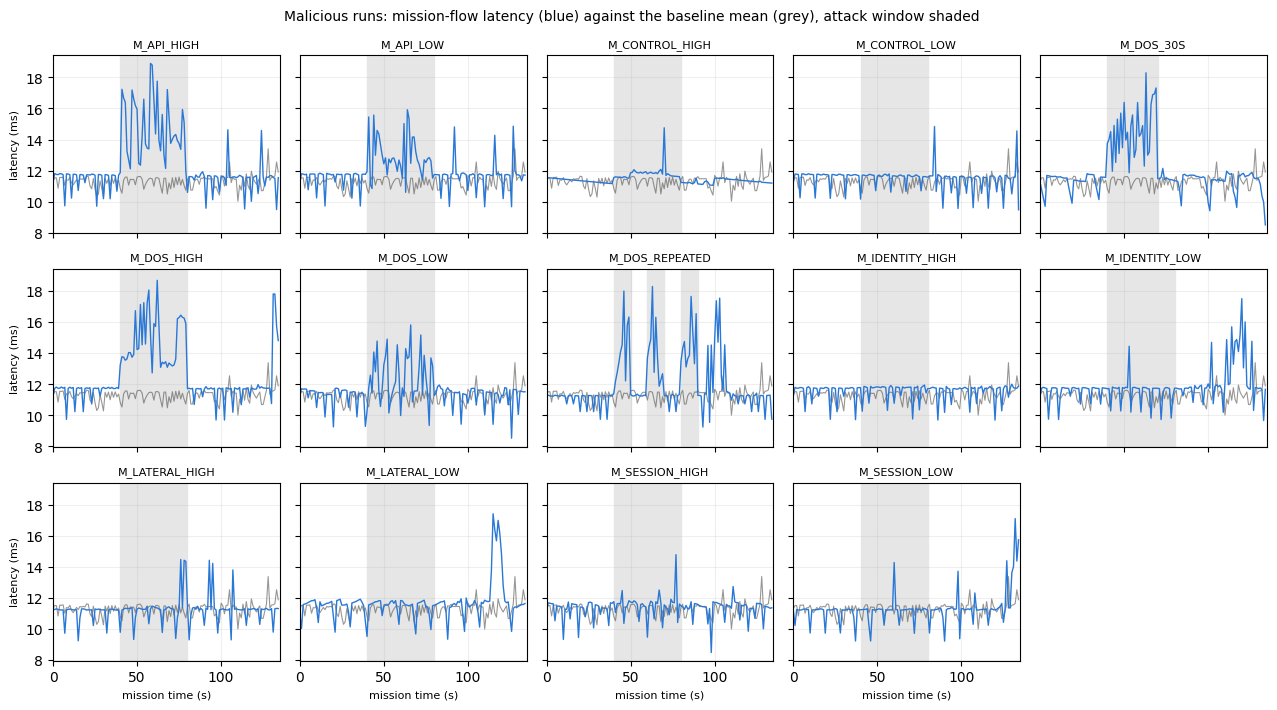

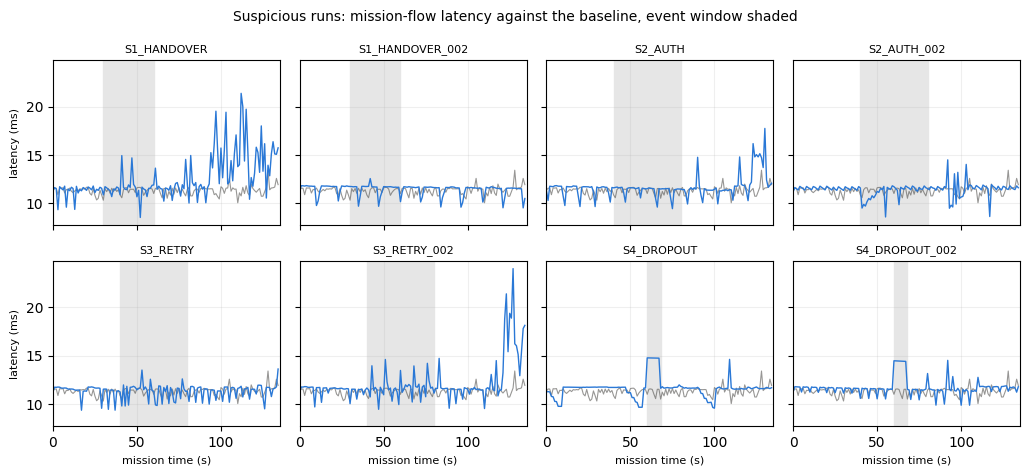

In [9]:
per_second = mission.groupby(["mission_id", "second"]).latency_ms.mean()
base_curve = per_second.loc[BASELINE].groupby("second").mean()


def panels(runs, columns, title):
    rows_n = -(-len(runs) // columns)
    figure, axes = plt.subplots(rows_n, columns, figsize=(2.6 * columns, 2.4 * rows_n), sharex=True, sharey=True)
    for axis in axes.ravel()[len(runs):]:
        axis.axis("off")
    for axis, run in zip(axes.ravel(), runs):
        for a, b in event_window(run):
            axis.axvspan(a, b, color="0.9", zorder=0)
        axis.plot(base_curve.index, base_curve.values, color=GREY, linewidth=0.8, alpha=0.6)
        curve = per_second.loc[run]
        axis.plot(curve.index, curve.values, color=BLUE, linewidth=1)
        axis.set_title(run.replace("_001", ""), fontsize=8)
        axis.grid(alpha=0.2)
        axis.set_xlim(0, 135)
    for axis in axes[:, 0]:
        axis.set_ylabel("latency (ms)", fontsize=8)
    for axis in axes[-1, :]:
        axis.set_xlabel("mission time (s)", fontsize=8)
    figure.suptitle(title, fontsize=10)
    figure.tight_layout()
    plt.show()


panels([r for r in RUNS if r.startswith("M_")], 5,
       "Malicious runs: mission-flow latency (blue) against the baseline mean (grey), attack window shaded")
panels([r for r in RUNS if r.startswith("S")], 4,
       "Suspicious runs: mission-flow latency against the baseline, event window shaded")

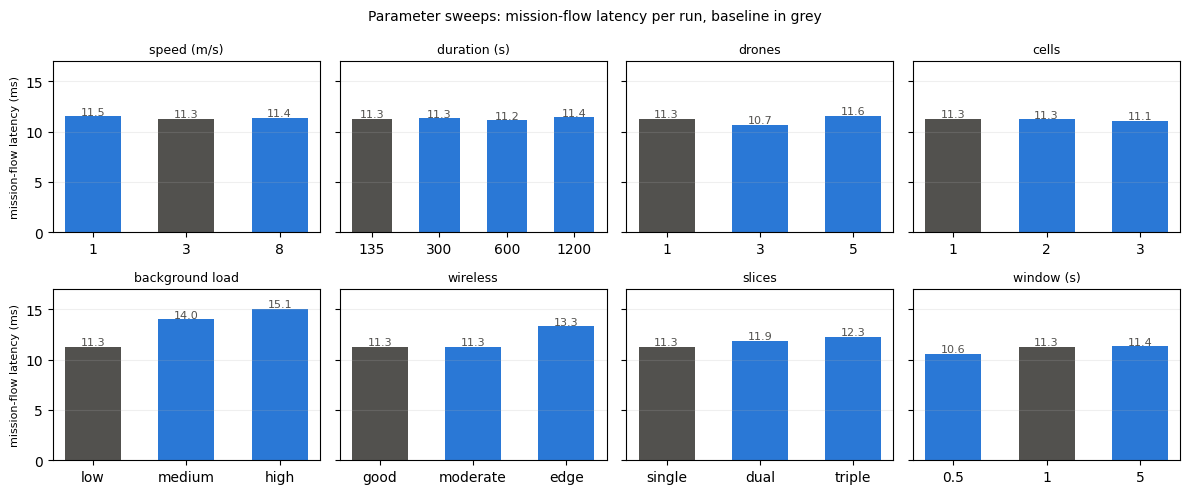

In [10]:
latency = mission.groupby("mission_id").latency_ms.mean()
SWEEPS = {
    "speed (m/s)": [("1", "B_SPEED_SLOW_001"), ("3", "baseline"), ("8", "B_SPEED_FAST_001")],
    "duration (s)": [("135", "baseline"), ("300", "B_DURATION_5_001"), ("600", "B_DURATION_10_001"), ("1200", "B_DURATION_20_001")],
    "drones": [("1", "baseline"), ("3", "B_DRONES_3_001"), ("5", "B_DRONES_5_001")],
    "cells": [("1", "baseline"), ("2", "B_CELLS_2_001"), ("3", "B_CELLS_3_001")],
    "background load": [("low", "baseline"), ("medium", "B_LOAD_MEDIUM_001"), ("high", "B_LOAD_HIGH_001")],
    "wireless": [("good", "baseline"), ("moderate", "B_WIRELESS_MODERATE_001"), ("edge", "B_WIRELESS_EDGE_001")],
    "slices": [("single", "baseline"), ("dual", "B_SLICE_DUAL_001"), ("triple", "B_SLICE_TRIPLE_001")],
    "window (s)": [("0.5", "B_WINDOW_0P5_001"), ("1", "baseline"), ("5", "B_WINDOW_5_001")],
}
figure, axes = plt.subplots(2, 4, figsize=(12, 5), sharey=True)
for axis, (group, points) in zip(axes.ravel(), SWEEPS.items()):
    labels = [label for label, _ in points]
    values = [latency.loc[BASELINE].mean() if run == "baseline" else latency[run] for _, run in points]
    colors = [GREY if run == "baseline" else BLUE for _, run in points]
    axis.bar(labels, values, color=colors, width=0.6)
    for i, value in enumerate(values):
        axis.text(i, value + 0.15, f"{value:.1f}", ha="center", fontsize=8, color=GREY)
    axis.set_title(group, fontsize=9)
    axis.set_ylim(0, 17)
    axis.grid(alpha=0.2, axis="y")
for axis in axes[:, 0]:
    axis.set_ylabel("mission-flow latency (ms)", fontsize=8)
figure.suptitle("Parameter sweeps: mission-flow latency per run, baseline in grey", fontsize=10)
figure.tight_layout()
plt.show()

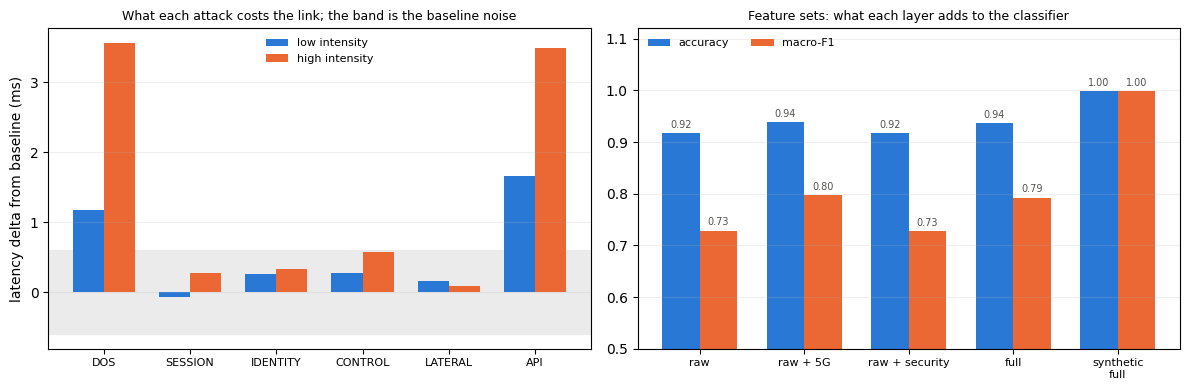

In [11]:
ATTACKS = ["DOS", "SESSION", "IDENTITY", "CONTROL", "LATERAL", "API"]
low = [measured.loc[f"M_{a}_LOW_001", "d_latency_ms"] for a in ATTACKS]
high = [measured.loc[f"M_{a}_HIGH_001", "d_latency_ms"] for a in ATTACKS]
position = np.arange(len(ATTACKS))

figure, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
left.bar(position - 0.18, low, 0.36, color=BLUE, label="low intensity")
left.bar(position + 0.18, high, 0.36, color=ORANGE, label="high intensity")
left.axhspan(-NOISE_MS, NOISE_MS, color="0.92", zorder=0)
left.set_xticks(position, ATTACKS, fontsize=8)
left.set_ylabel("latency delta from baseline (ms)")
left.set_title("What each attack costs the link; the band is the baseline noise", fontsize=9)
left.legend(fontsize=8, frameon=False)
left.grid(alpha=0.2, axis="y")

metrics = [line.split("|")[1:-1] for line in (HERE / "reports/model_metrics.md").read_text().splitlines()
           if line.startswith("| Co-simulation") or line.startswith("| Synthetic")]
SHORT = {"raw metrics only": "raw", "raw + 5G context": "raw + 5G", "raw + security indicators": "raw + security",
         "full feature set": "full"}
names = [("synthetic\n" if d.startswith(" Synthetic") else "") + SHORT[f.strip()] for d, f, _, _ in metrics]
accuracy = [float(a) for _, _, a, _ in metrics]
macro_f1 = [float(m) for _, _, _, m in metrics]
position = np.arange(len(names))
right.bar(position - 0.18, accuracy, 0.36, color=BLUE, label="accuracy")
right.bar(position + 0.18, macro_f1, 0.36, color=ORANGE, label="macro-F1")
for i, (a, m) in enumerate(zip(accuracy, macro_f1)):
    right.text(i - 0.18, a + 0.01, f"{a:.2f}", ha="center", fontsize=7, color=GREY)
    right.text(i + 0.18, m + 0.01, f"{m:.2f}", ha="center", fontsize=7, color=GREY)
right.set_xticks(position, names, fontsize=8)
right.set_ylim(0.5, 1.12)
right.set_title("Feature sets: what each layer adds to the classifier", fontsize=9)
right.legend(fontsize=8, frameon=False, loc="upper left", ncol=2)
right.grid(alpha=0.2, axis="y")
figure.tight_layout()
plt.show()

### 6.3 Realism gaps against the synthetic reference

The synthetic dataset and this one agree on the schema and on the direction of
every effect, and disagree on scale. From `reports/distribution_comparison.md`:

- **Traffic volume.** The synthetic rows carry a median of 84 packets per
  second and 669 kbit/s; here the median is 25 packets per second and 21
  kbit/s, because the flows are a real telemetry stream at 50 Hz and a command
  stream at 1 Hz, not an aggregate over a whole network segment.
- **Delay.** Synthetic latency has a mean of 78 ms with a standard deviation of
  82 ms; here it is 11.6 ms with 3.3 ms. Simu5G models one lightly loaded cell
  with a wired core, and nothing in the matrix drives it past about 20 ms. The
  synthetic malicious rows average 165 ms; the worst attack here adds 3.6 ms.
- **Loss and jitter** follow the same pattern: synthetic loss averages 3.2
  percent, here 0.7 percent; synthetic jitter 18 ms, here 0.5 ms.
- **Components.** The synthetic rows are spread evenly over drone, 5G core,
  backend and security monitor as sources; 97 percent of the rows here have the
  drone as source, because only the radio leg is measured per flow.
- **Label balance.** The synthetic set is 61 percent normal, 19 percent
  suspicious, 20 percent malicious; this one is 86, 5 and 9 percent, since
  attacks occupy 40 s of a 135 s mission and most runs are benign variations.
- **anomaly_score** is populated in the synthetic set and zero here, as the
  document allows; **signal quality** sits at -57 dBm here against -75 dBm,
  the synthetic set describing a poorer radio environment throughout.

What the co-simulation offers that the synthetic set cannot is provenance:
every value traces to a recorded flight and a Simu5G vector, the flags are
reproduced from behaviour with zero mismatches, and the near-perfect synthetic
accuracy of 0.999 gives way to 0.94, which is the honest difficulty of telling
a congested link from an attacked one.

### 6.4 Deliverables gate

Every file the experiment document lists, checked on disk.

In [12]:
checks = []
for run in RUNS:
    drones = manifests[run]["simulation"]["drone_count"]
    suffixes = [""] + [f"_d{d}" for d in range(1, drones)]
    checks += [
        (f"{run} manifest", (HERE / "manifests" / f"{run}.yaml").is_file()),
        (f"{run} ROS 2 bag(s)", all((HERE / "logs" / run / f"rosbag{s}/metadata.yaml").is_file() for s in suffixes)),
        (f"{run} pose trace(s)", all((HERE / "trace" / f"{run}_pose{s}.txt").is_file() for s in suffixes)),
        (f"{run} Simu5G results", (HERE / "logs" / run / "network/results/baseline.vec").is_file()),
        (f"{run} network CSV", (HERE / "logs" / f"{run}_net.csv").is_file()),
        (f"{run} bridge log", (HERE / "logs" / run / "bridge.log").is_file()),
        (f"{run} dataset", (HERE / "data" / f"{run}_cosim.csv").is_file()),
        (f"{run} validation", "PASSED" in (HERE / "reports" / f"{run}_validation.txt").read_text()),
    ]
checks += [
    ("bridge scripts", all((HERE / "sim/bridge" / s).is_file() for s in ("assemble.py", "concat.py", "export_pose_trace.py"))),
    ("final dataset", FINAL.is_file()),
    ("final dataset validates", subprocess.run([sys.executable, "validate_dataset.py", str(FINAL), "schema_reference.json"],
                                               cwd=HERE, capture_output=True, text=True).stdout.startswith("RESULT: PASSED")),
    ("validation report", (HERE / "reports/validation_report.md").is_file()),
    ("model comparison report", (HERE / "reports/model_metrics.md").is_file()),
    ("distribution comparison", (HERE / "reports/distribution_comparison.md").is_file()),
]
missing = [name for name, ok in checks if not ok]
print(f"{len(checks) - len(missing)} of {len(checks)} deliverable checks pass")
assert not missing, missing

350 of 350 deliverable checks pass
